## ⚙️ VÒNG 4: PRESCRIPTIVE — Rule Engine + Báo cáo Tự động

**Mục tiêu:**
- Áp **3 rule kiểm toán** lên từng ca để phân loại nguyên nhân sai lệch
- Tích hợp dữ liệu khách quen từ Vòng 3 để cờ đơn lệch thói quen thanh toán
- Sinh **báo cáo text tự động** không cần LLM — plain Python + f-string template

**Input:** `data/Audit_Merged_Data.csv` + `data/Clustered_Shifts.csv` + `data/Customer_Pattern.csv`  
**Output:** `data/Rule_Engine_Report.csv` + báo cáo in-notebook

---
| Rule | Điều kiện | Phán quyết |
|------|-----------|-----------|
| R1 | `Cash_Diff < 0` & `Payment_Mismatch > 0` cùng chiều | Nhầm loại tiền |
| R2 | `Cash_Diff < 0` & `Payment_Mismatch = 0` | Nghi thất thoát thực |
| R3 | Ca có đơn khách quen + thanh toán lệch thói quen | Kiểm tra đơn cụ thể |

> **Lưu ý về dữ liệu:** Trong dataset này `Payment_Mismatch = 0` ở tất cả ca (tổng tiền mặt bill khớp hoàn toàn với máy chốt). Do đó Rule 1 không kích hoạt, và toàn bộ ca có `Cash_Diff < 0` rơi vào Rule 2. Rule 3 hoạt động độc lập trên dữ liệu khách quen.


## 0. Import & Config

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# ── Màu rule ──────────────────────────────────────────────────────────────────
RULE_COLORS = {
    'R1_Nham_Loai_Tien' : '#e67e22',   # cam   — nhầm loại tiền
    'R2_That_Thoat_Thuc': '#e74c3c',   # đỏ    — thất thoát thực
    'R3_Khach_Quen'     : '#9b59b6',   # tím   — bất thường khách quen
    'CLEAR'             : '#2ecc71',   # xanh  — ca sạch
}

RULE_LABELS = {
    'R1_Nham_Loai_Tien' : '⚠️  R1: Nhầm Loại Tiền',
    'R2_That_Thoat_Thuc': '🔴 R2: Nghi Thất Thoát',
    'R3_Khach_Quen'     : '🔵 R3: Khách Quen Lệch',
    'CLEAR'             : '✅ Bình Thường',
}

def fmt_vnd(x):
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.2f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.0f}k"
    return f"{x:.0f}"

print("✅ Đã load thư viện thành công.")


✅ Đã load thư viện thành công.


---
## 1. Load Data

In [12]:
# Load toàn bộ input từ 3 vòng trước
df_audit    = pd.read_csv('./data/Audit_Merged_Data.csv')
df_cluster  = pd.read_csv('./data/Clustered_Shifts.csv')
df_customer = pd.read_csv('./data/Customer_Pattern.csv')

# Parse datetime
df_audit['timestamp']       = pd.to_datetime(df_audit['timestamp'])
df_cluster['timestamp']     = pd.to_datetime(df_cluster['timestamp'])
df_customer['transaction_at'] = pd.to_datetime(df_customer['transaction_at'])

# Gộp cluster_label vào audit (nếu chưa có)
df = df_audit.copy()
if 'cluster_label' not in df.columns:
    df = df.merge(
        df_cluster[['shift_id','cluster_label','CashDiff_Ratio','Avg_Bill_Value']],
        on='shift_id', how='left'
    )

df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Tổng số ca: {len(df)}")
print(f"Khoảng thời gian: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print()
print("Phân bổ cluster:")
print(df['cluster_label'].value_counts().to_string())


Tổng số ca: 236
Khoảng thời gian: 2025-12-20 → 2026-04-30

Phân bổ cluster:
cluster_label
C3: Tải Cao              110
C1: Bình Thường           96
C2: Tích Lũy Đặc Biệt     28
C0: Dư Két Cao             2


---
## 2. Bảng Thói Quen Khách — Cơ sở cho Rule 3

In [13]:
# ── Tính thói quen thanh toán cho từng nhóm khách ─────────────────────────
customer_habits_raw = df_customer[
    df_customer['customer_group'].isin(['ngoc_pt','c_hai','c_trang','ban_chu_tho'])
].groupby('customer_group').agg(
    so_don        = ('total_revenue', 'count'),
    avg_rev       = ('total_revenue', 'mean'),
    transfer_sum  = ('transfer_payment', 'sum'),
    cash_sum      = ('cash_payment', 'sum'),
    revenue_sum   = ('total_revenue', 'sum'),
).reset_index()

customer_habits_raw['pct_ck'] = (
    customer_habits_raw['transfer_sum'] / customer_habits_raw['revenue_sum'] * 100
).round(1)

customer_habits_raw['dominant'] = customer_habits_raw['pct_ck'].apply(
    lambda p: 'transfer' if p >= 60 else ('cash' if p <= 40 else 'mixed')
)

# Ngưỡng bất thường: đơn > avg + 2σ
std_map = df_customer.groupby('customer_group')['total_revenue'].std().to_dict()
customer_habits_raw['std_rev'] = customer_habits_raw['customer_group'].map(std_map).fillna(0)
customer_habits_raw['threshold_high'] = (
    customer_habits_raw['avg_rev'] + 2 * customer_habits_raw['std_rev']
).round(0)

customer_habits = customer_habits_raw.set_index('customer_group').to_dict(orient='index')

CUSTOMER_LABELS_MAP = {
    'ngoc_pt':     'Ngọc PT',
    'c_hai':       'C Hải',
    'c_trang':     'C Trang',
    'ban_chu_tho': 'Bạn Chú Thọ',
}

print("📊 BẢNG THÓI QUEN THANH TOÁN KHÁCH QUEN:")
display_df = customer_habits_raw.copy()
display_df['label'] = display_df['customer_group'].map(CUSTOMER_LABELS_MAP)
display_df['avg_rev'] = display_df['avg_rev'].round(0)
display(display_df[['label','so_don','avg_rev','threshold_high','pct_ck','dominant']].rename(columns={
    'label': 'Khách',
    'so_don': 'Số đơn',
    'avg_rev': 'ĐTB (đ)',
    'threshold_high': 'Ngưỡng cao (đ)',
    'pct_ck': '% CK thói quen',
    'dominant': 'Phương thức chính',
}))


📊 BẢNG THÓI QUEN THANH TOÁN KHÁCH QUEN:


,Khách,Số đơn,ĐTB (đ),Ngưỡng cao (đ),% CK thói quen,Phương thức chính
0,Bạn Chú Thọ,2,52000.0,145338.0,0.0,cash
1,C Hải,25,87080.0,238458.0,36.9,cash
2,C Trang,9,383111.0,843069.0,92.2,transfer
3,Ngọc PT,57,31000.0,58635.0,90.0,transfer


---
## 3. Ghép Đơn Khách Quen vào Ca

In [14]:
# ── merge_asof: ghép mỗi txn khách → ca chốt ngay sau nó ─────────────────
cust_sorted   = df_customer.sort_values('transaction_at')
shifts_sorted = df[['shift_id','timestamp']].sort_values('timestamp')

cust_mapped = pd.merge_asof(
    cust_sorted,
    shifts_sorted,
    left_on='transaction_at',
    right_on='timestamp',
    direction='forward'
)
cust_mapped = cust_mapped.dropna(subset=['shift_id'])
cust_mapped['shift_id'] = cust_mapped['shift_id'].astype(int)

# Xác định bất thường thanh toán
def flag_payment_anomaly(row):
    grp = row['customer_group']
    if grp not in customer_habits:
        return False
    dom = customer_habits[grp]['dominant']
    if dom == 'transfer' and row['cash_payment'] > 0:
        return True
    if dom == 'cash' and row['transfer_payment'] > 0:
        return True
    return False

def flag_value_anomaly(row):
    grp = row['customer_group']
    if grp not in customer_habits:
        return False
    threshold = customer_habits[grp]['threshold_high']
    return row['total_revenue'] > threshold

cust_mapped['payment_anomaly'] = cust_mapped.apply(flag_payment_anomaly, axis=1)
cust_mapped['value_anomaly']   = cust_mapped.apply(flag_value_anomaly, axis=1)
cust_mapped['any_anomaly']     = cust_mapped['payment_anomaly'] | cust_mapped['value_anomaly']

# Group anomalies per shift
shift_customer_alerts = (
    cust_mapped[cust_mapped['any_anomaly']]
    .groupby('shift_id')
    .apply(lambda g: g[[
        'transaction_at','customer_label','total_revenue',
        'cash_payment','transfer_payment','payment_anomaly','value_anomaly'
    ]].to_dict(orient='records'))
    .to_dict()
)

print(f"Ca có đơn khách quen: {cust_mapped['shift_id'].nunique()}")
print(f"Ca có cảnh báo Rule 3: {len(shift_customer_alerts)}")
print(f"Tổng đơn bất thường (Rule 3): {cust_mapped['any_anomaly'].sum()}")


Ca có đơn khách quen: 85
Ca có cảnh báo Rule 3: 20
Tổng đơn bất thường (Rule 3): 21


---
## 4. Rule Engine — Phân loại Từng Ca

**Thứ tự ưu tiên rule:**
1. R1 kích hoạt khi `Cash_Diff < 0` **và** `Payment_Mismatch > 0` (cùng chiều)
2. R2 kích hoạt khi `Cash_Diff < 0` **và** `Payment_Mismatch = 0`
3. R3 kích hoạt **độc lập** dựa trên anomaly khách quen (có thể đồng thời với R2)
4. `CLEAR` = không kích hoạt rule nào


In [15]:
# ── Thresholds ────────────────────────────────────────────────────────────
THRESHOLD_CASH_DIFF  = -5_000    # Cash_Diff < ngưỡng này → xét rule
THRESHOLD_MISMATCH   =  5_000    # |Payment_Mismatch| > ngưỡng này → R1

def apply_rules(row, customer_alerts):
    """
    Áp dụng 3 rule lên một ca.
    Trả về dict với danh sách rule kích hoạt + chi tiết.
    """
    rules_fired = []
    details     = []
    shift_id    = int(row['shift_id'])
    cd          = row['Cash_Diff']
    pm          = row['Payment_Mismatch']

    # ── Rule 1: Nhầm loại tiền ─────────────────────────────────────────────
    # Cả Cash_Diff âm VÀ Payment_Mismatch dương → bill ghi tiền mặt nhiều hơn
    # máy chốt, nhưng két lại thiếu → khả năng nhầm ký loại CK thành tiền mặt
    if cd < THRESHOLD_CASH_DIFF and pm > THRESHOLD_MISMATCH:
        rules_fired.append('R1_Nham_Loai_Tien')
        details.append(
            f"R1 | Két hụt {fmt_vnd(abs(cd))} đ, lệch đối soát bill +{fmt_vnd(pm)} đ → "
            f"nghi nhầm loại tiền (bấm tiền mặt thừa {fmt_vnd(pm)} đ)."
        )

    # ── Rule 2: Thất thoát thực ────────────────────────────────────────────
    # Két thiếu nhưng bill khớp hoàn toàn → tiền biến mất sau khi bill đã ghi
    elif cd < THRESHOLD_CASH_DIFF and abs(pm) <= THRESHOLD_MISMATCH:
        rules_fired.append('R2_That_Thoat_Thuc')
        details.append(
            f"R2 | Két hụt {fmt_vnd(abs(cd))} đ, đối soát bill khớp (PM={fmt_vnd(pm)}) → "
            f"nghi thất thoát tiền mặt thực tế."
        )

    # ── Rule 3: Khách quen lệch thói quen ─────────────────────────────────
    # Kích hoạt độc lập — không liên quan Cash_Diff
    if shift_id in customer_alerts:
        rules_fired.append('R3_Khach_Quen')
        for alert in customer_alerts[shift_id]:
            label   = alert['customer_label']
            rev     = alert['total_revenue']
            cash    = alert['cash_payment']
            ck      = alert['transfer_payment']
            at_str  = pd.to_datetime(alert['transaction_at']).strftime('%H:%M %d/%m')
            grp_key = next((k for k,v in CUSTOMER_LABELS_MAP.items() if v == label), None)
            habit   = customer_habits.get(grp_key, {})
            dom     = habit.get('dominant', '?')
            pct     = habit.get('pct_ck', 0)

            if alert['payment_anomaly']:
                actual_method = 'tiền mặt' if cash > 0 else 'chuyển khoản'
                usual_method  = 'chuyển khoản' if dom == 'transfer' else 'tiền mặt'
                details.append(
                    f"R3 | Đơn {label} lúc {at_str}: {fmt_vnd(rev)} đ trả {actual_method} "
                    f"(thói quen {pct:.0f}% {usual_method}) → kiểm tra lại."
                )
            if alert['value_anomaly']:
                avg_rev = habit.get('avg_rev', 0)
                details.append(
                    f"R3 | Đơn {label} lúc {at_str}: {fmt_vnd(rev)} đ cao bất thường "
                    f"(TB {fmt_vnd(avg_rev)} đ) → kiểm tra lại."
                )

    # ── Xác định severity ──────────────────────────────────────────────────
    if 'R2_That_Thoat_Thuc' in rules_fired and 'R3_Khach_Quen' in rules_fired:
        severity = 'CAO'   # thất thoát + khách lệch → nguy hiểm nhất
    elif 'R2_That_Thoat_Thuc' in rules_fired:
        severity = 'TRUNG BÌNH'
    elif 'R1_Nham_Loai_Tien' in rules_fired:
        severity = 'THẤP'
    elif 'R3_Khach_Quen' in rules_fired:
        severity = 'CHÚ Ý'
    else:
        severity = '-'

    # Nếu không có rule nào → CLEAR
    primary_rule = rules_fired[0] if rules_fired else 'CLEAR'

    return {
        'rules_fired'   : rules_fired,
        'primary_rule'  : primary_rule,
        'severity'      : severity,
        'detail_lines'  : details,
        'has_alert'     : len(rules_fired) > 0,
    }

# ── Áp dụng toàn bộ ca ────────────────────────────────────────────────────
rule_results = []
for _, row in df.iterrows():
    result = apply_rules(row, shift_customer_alerts)
    rule_results.append(result)

df['rules_fired']  = [r['rules_fired']  for r in rule_results]
df['primary_rule'] = [r['primary_rule'] for r in rule_results]
df['severity']     = [r['severity']     for r in rule_results]
df['detail_lines'] = [r['detail_lines'] for r in rule_results]
df['has_alert']    = [r['has_alert']    for r in rule_results]

# ── Summary ───────────────────────────────────────────────────────────────
print("📊 KẾT QUẢ PHÂN LOẠI RULE ENGINE:")
print(f"{'Rule':<30} {'Số ca':>7} {'%':>6}")
print("-" * 46)
for rule, lbl in RULE_LABELS.items():
    cnt = (df['primary_rule'] == rule).sum()
    print(f"  {lbl:<28} {cnt:>7}  ({cnt/len(df)*100:.1f}%)")
print(f"  {'Tổng':.<28} {len(df):>7}")


📊 KẾT QUẢ PHÂN LOẠI RULE ENGINE:
Rule                             Số ca      %
----------------------------------------------
  ⚠️  R1: Nhầm Loại Tiền             0  (0.0%)
  🔴 R2: Nghi Thất Thoát             11  (4.7%)
  🔵 R3: Khách Quen Lệch             20  (8.5%)
  ✅ Bình Thường                    205  (86.9%)
  Tổng........................     236


---
## 5. Báo cáo Text Tự động

Hàm `generate_report()` nhận một ca và in báo cáo dạng văn bản mô tả rõ vấn đề.  
Không dùng LLM — thuần template f-string với logic rẽ nhánh theo rule.


In [16]:
def generate_report(row, verbose=True):
    """
    Sinh báo cáo text tự động cho một ca.
    verbose=True: in đầy đủ | verbose=False: trả về string ngắn.
    """
    ts        = pd.to_datetime(row['timestamp'])
    date_str  = ts.strftime('%d/%m/%Y')
    time_str  = ts.strftime('%H:%M')
    shift_name = row['Shift_Name']
    shift_id  = int(row['shift_id'])
    rev       = row['total_revenue']
    cd        = row['Cash_Diff']
    pm        = row['Payment_Mismatch']
    bills     = int(row['bill_count'])
    cluster   = row.get('cluster_label', '—')
    primary   = row['primary_rule']
    severity  = row['severity']
    details   = row['detail_lines']

    # ── Header ────────────────────────────────────────────────────────────
    sev_icon = {'CAO':'🔴','TRUNG BÌNH':'🟠','THẤP':'🟡','CHÚ Ý':'🔵','-':'✅'}.get(severity,'❓')
    lines = [
        f"{'─'*60}",
        f"CA #{shift_id:03d} | {shift_name} | {date_str} {time_str}",
        f"Doanh thu: {fmt_vnd(rev)} đ  |  {bills} bill  |  Cụm: {cluster}",
        f"Trạng thái: {sev_icon} {severity}",
        f"{'─'*60}",
    ]

    # ── Body theo rule ─────────────────────────────────────────────────────
    if primary == 'CLEAR' and not details:
        lines.append("  ✅ Ca không có bất thường. Két khớp, đối soát đúng.")
    else:
        lines.append("  Phát hiện:")
        for d in details:
            lines.append(f"    • {d}")

        # Gợi ý hành động
        lines.append("")
        lines.append("  Hành động đề xuất:")
        if 'R2_That_Thoat_Thuc' in row['rules_fired']:
            lines.append(f"    → Đối chiếu lại két với nhân viên ca {shift_name} ngày {date_str}.")
            lines.append(f"    → Kiểm tra camera / sổ tay nếu hụt ≥ 100k ({fmt_vnd(abs(cd))} đ).")
        if 'R1_Nham_Loai_Tien' in row['rules_fired']:
            lines.append(f"    → Xem lại từng bill trong ca: tìm bill bấm nhầm CK thành tiền mặt.")
            lines.append(f"    → Số tiền cần tìm: ~{fmt_vnd(pm)} đ.")
        if 'R3_Khach_Quen' in row['rules_fired']:
            lines.append(f"    → Liên hệ xác nhận với khách: đúng phương thức thanh toán chưa?")
            lines.append(f"    → Nếu là đơn lớn bất thường, kiểm tra xem hàng đã giao đủ chưa.")

    report_str = '\n'.join(lines)
    if verbose:
        print(report_str)
    return report_str

# ── Demo: in báo cáo cho ca có alert ──────────────────────────────────────
alert_rows = df[df['has_alert']].head(6)
print(f"In báo cáo cho {len(alert_rows)} ca đầu tiên có cảnh báo:\n")
for _, row in alert_rows.iterrows():
    generate_report(row, verbose=True)
    print()


In báo cáo cho 6 ca đầu tiên có cảnh báo:

────────────────────────────────────────────────────────────
CA #001 | Ca Chiều | 20/12/2025 17:54
Doanh thu: 462k đ  |  16 bill  |  Cụm: C3: Tải Cao
Trạng thái: 🟠 TRUNG BÌNH
────────────────────────────────────────────────────────────
  Phát hiện:
    • R2 | Két hụt 211k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế.

  Hành động đề xuất:
    → Đối chiếu lại két với nhân viên ca Ca Chiều ngày 20/12/2025.
    → Kiểm tra camera / sổ tay nếu hụt ≥ 100k (211k đ).

────────────────────────────────────────────────────────────
CA #002 | Ca Sáng | 21/12/2025 11:45
Doanh thu: 544k đ  |  17 bill  |  Cụm: C3: Tải Cao
Trạng thái: 🟠 TRUNG BÌNH
────────────────────────────────────────────────────────────
  Phát hiện:
    • R2 | Két hụt 418k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế.

  Hành động đề xuất:
    → Đối chiếu lại két với nhân viên ca Ca Sáng ngày 21/12/2025.
    → Kiểm tra camera / sổ tay nếu hụt ≥ 100k (4

---
## 6. Báo cáo Hàng Loạt — Tổng hợp Theo Tháng

In [17]:
def generate_monthly_summary(df_month, month_str):
    """Báo cáo tóm tắt cho một tháng."""
    total_shifts = len(df_month)
    alert_shifts = df_month['has_alert'].sum()

    r1 = (df_month['primary_rule'] == 'R1_Nham_Loai_Tien').sum()
    r2 = (df_month['primary_rule'] == 'R2_That_Thoat_Thuc').sum()
    r3 = (df_month['rules_fired'].apply(lambda x: 'R3_Khach_Quen' in x)).sum()
    clear = total_shifts - alert_shifts

    r2_df       = df_month[df_month['primary_rule'] == 'R2_That_Thoat_Thuc']
    total_loss  = r2_df['Cash_Diff'].sum()  # âm = hụt
    worst_shift = r2_df.loc[r2_df['Cash_Diff'].idxmin()] if len(r2_df) else None

    lines = [
        f"",
        f"{'═'*60}",
        f"  BÁO CÁO THÁNG {month_str}",
        f"{'═'*60}",
        f"  Tổng ca: {total_shifts}  |  Ca có cảnh báo: {alert_shifts} ({alert_shifts/total_shifts*100:.0f}%)",
        f"",
        f"  Phân loại:",
        f"    ✅ Bình thường          : {clear:>4} ca",
        f"    🟡 R1 Nhầm loại tiền   : {r1:>4} ca",
        f"    🟠 R2 Nghi thất thoát  : {r2:>4} ca  (tổng hụt két: {fmt_vnd(abs(total_loss))} đ)",
        f"    🔵 R3 Khách quen lệch  : {r3:>4} ca",
    ]

    if worst_shift is not None:
        wts = pd.to_datetime(worst_shift['timestamp']).strftime('%d/%m %H:%M')
        lines.append(f"")
        lines.append(f"  Ca hụt két nặng nhất: #{int(worst_shift['shift_id']):03d} | {wts} | {fmt_vnd(abs(worst_shift['Cash_Diff']))} đ")

    lines.append(f"{'═'*60}")
    return '\n'.join(lines)

# ── Sinh báo cáo tháng cho toàn bộ dataset ────────────────────────────────
df['month'] = df['timestamp'].dt.to_period('M').astype(str)

full_report_lines = []
for month in sorted(df['month'].unique()):
    df_m = df[df['month'] == month]
    summary = generate_monthly_summary(df_m, month)
    full_report_lines.append(summary)
    print(summary)



════════════════════════════════════════════════════════════
  BÁO CÁO THÁNG 2025-12
════════════════════════════════════════════════════════════
  Tổng ca: 24  |  Ca có cảnh báo: 7 (29%)

  Phân loại:
    ✅ Bình thường          :   17 ca
    🟡 R1 Nhầm loại tiền   :    0 ca
    🟠 R2 Nghi thất thoát  :    5 ca  (tổng hụt két: 1.84M đ)
    🔵 R3 Khách quen lệch  :    2 ca

  Ca hụt két nặng nhất: #006 | 23/12 11:42 | 556k đ
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  BÁO CÁO THÁNG 2026-01
════════════════════════════════════════════════════════════
  Tổng ca: 60  |  Ca có cảnh báo: 6 (10%)

  Phân loại:
    ✅ Bình thường          :   54 ca
    🟡 R1 Nhầm loại tiền   :    0 ca
    🟠 R2 Nghi thất thoát  :    2 ca  (tổng hụt két: 353k đ)
    🔵 R3 Khách quen lệch  :    4 ca

  Ca hụt két nặng nhất: #033 | 05/01 17:28 | 181k đ
════════════════════════════════════════════════════════════

══════════════════════════

---
## 7. Visualize — Phân bố Rule Theo Thời gian

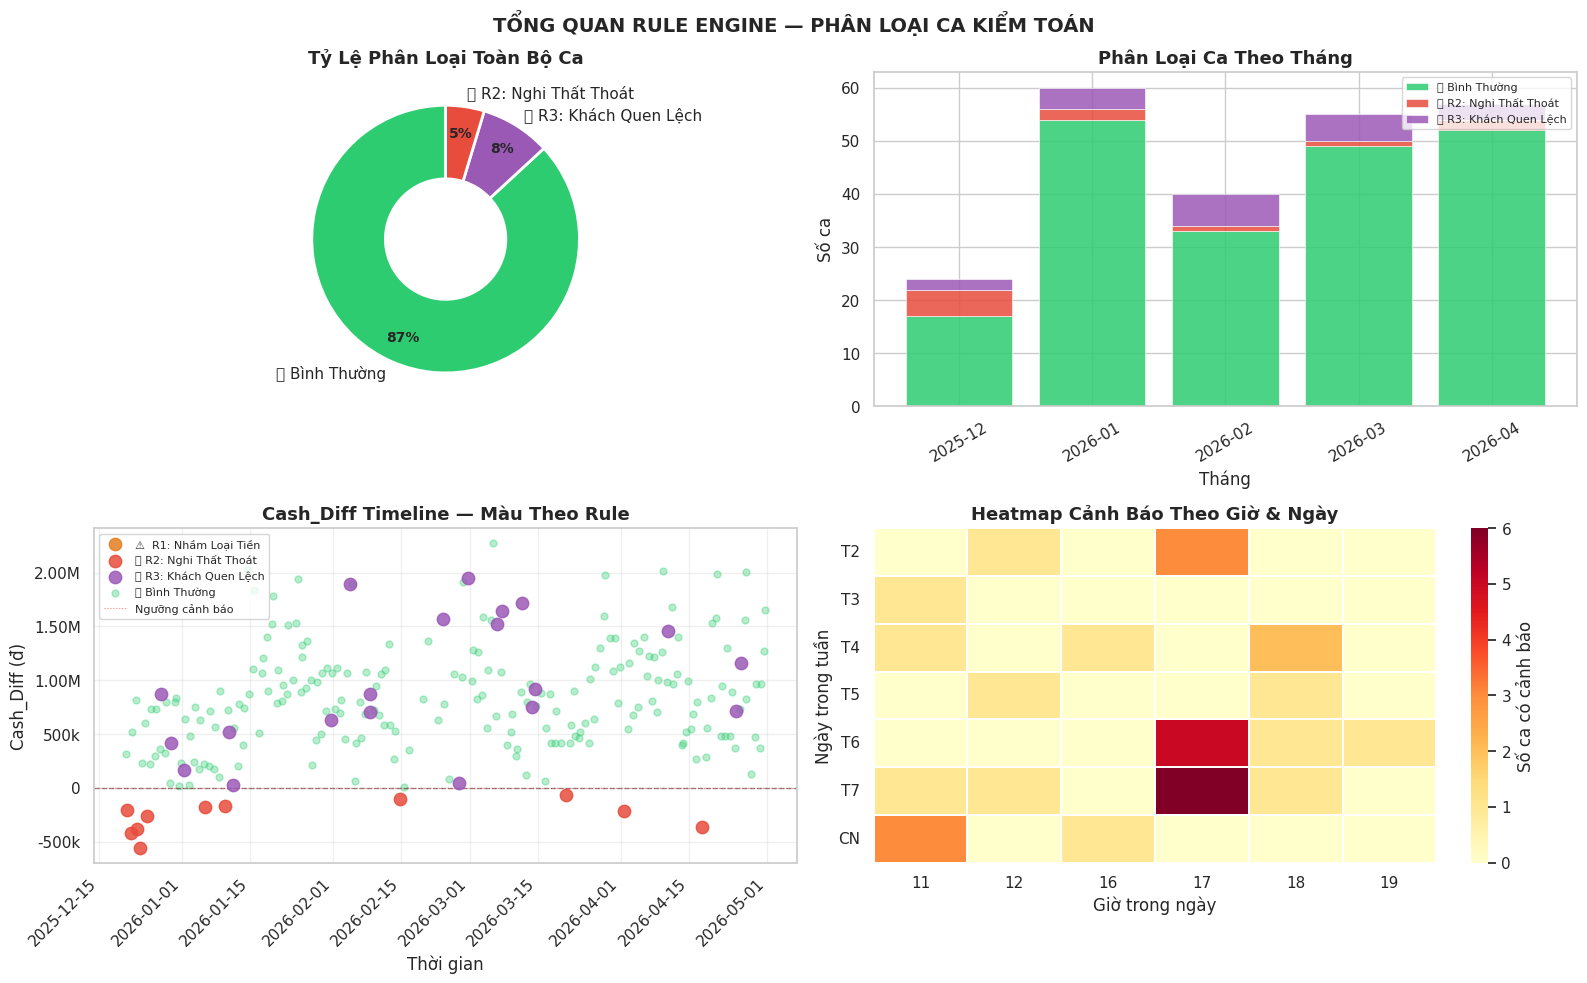

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Plot 1: Donut chart tỷ lệ rule ────────────────────────────────────────
ax = axes[0, 0]
rule_counts = df['primary_rule'].value_counts()
labels_pie  = [RULE_LABELS.get(r, r) for r in rule_counts.index]
colors_pie  = [RULE_COLORS.get(r, '#95a5a6') for r in rule_counts.index]
wedges, texts, autotexts = ax.pie(
    rule_counts.values, labels=labels_pie, colors=colors_pie,
    autopct='%1.0f%%', startangle=90, pctdistance=0.8,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('Tỷ Lệ Phân Loại Toàn Bộ Ca', fontweight='bold')

# ── Plot 2: Stacked bar theo tháng ─────────────────────────────────────────
ax = axes[0, 1]
pivot = df.groupby(['month','primary_rule']).size().unstack(fill_value=0)
rule_order = ['CLEAR','R1_Nham_Loai_Tien','R2_That_Thoat_Thuc','R3_Khach_Quen']
pivot = pivot.reindex(columns=[r for r in rule_order if r in pivot.columns])
bottom = np.zeros(len(pivot))
for rule in pivot.columns:
    color = RULE_COLORS.get(rule, '#95a5a6')
    ax.bar(pivot.index, pivot[rule], bottom=bottom, color=color,
           alpha=0.85, label=RULE_LABELS.get(rule, rule), edgecolor='white', linewidth=0.5)
    bottom += pivot[rule].values
ax.set_title('Phân Loại Ca Theo Tháng', fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Số ca')
ax.legend(fontsize=8, loc='upper right')
ax.tick_params(axis='x', rotation=30)

# ── Plot 3: Cash_Diff timeline với màu rule ────────────────────────────────
ax = axes[1, 0]
for rule, color in RULE_COLORS.items():
    mask = df['primary_rule'] == rule
    sub  = df[mask]
    size = 80 if rule != 'CLEAR' else 25
    alpha = 0.85 if rule != 'CLEAR' else 0.35
    ax.scatter(sub['timestamp'], sub['Cash_Diff'],
               color=color, s=size, alpha=alpha,
               label=RULE_LABELS.get(rule, rule), zorder=3 if rule != 'CLEAR' else 2)
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.axhline(-5000, color='red', linewidth=0.8, linestyle=':', alpha=0.5, label='Ngưỡng cảnh báo')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt_vnd(x)))
ax.set_title('Cash_Diff Timeline — Màu Theo Rule', fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Cash_Diff (đ)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

ax.tick_params(axis='x', rotation=45) # Xoay nghiêng 45 độ
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')

# ── Plot 4: Severity heatmap theo ngày trong tuần × giờ ───────────────────
ax = axes[1, 1]
df_alert = df[df['has_alert']].copy()
df_alert['dow']  = df_alert['timestamp'].dt.day_name()
df_alert['hour'] = df_alert['timestamp'].dt.hour

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_vi    = ['T2','T3','T4','T5','T6','T7','CN']
pivot_heat = df_alert.groupby(['dow','hour']).size().unstack(fill_value=0)
pivot_heat = pivot_heat.reindex([d for d in dow_order if d in pivot_heat.index])

if len(pivot_heat):
    sns.heatmap(pivot_heat, ax=ax, cmap='YlOrRd', linewidths=0.3,
                cbar_kws={'label': 'Số ca có cảnh báo'})
    ax.set_yticklabels(
        [dow_vi[dow_order.index(d)] if d in dow_order else d for d in pivot_heat.index],
        rotation=0
    )
    ax.set_xlabel('Giờ trong ngày')
    ax.set_ylabel('Ngày trong tuần')
else:
    ax.text(0.5, 0.5, 'Không đủ dữ liệu', ha='center', va='center', transform=ax.transAxes)
ax.set_title('Heatmap Cảnh Báo Theo Giờ & Ngày', fontweight='bold')

plt.suptitle('TỔNG QUAN RULE ENGINE — PHÂN LOẠI CA KIỂM TOÁN', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


---
## 8. Bảng Chi Tiết Ca Có Cảnh Báo

In [19]:
# ── Bảng tất cả ca có alert để tra cứu nhanh ─────────────────────────────
alert_df = df[df['has_alert']].copy()
alert_df['detail_text'] = alert_df['detail_lines'].apply(lambda x: ' | '.join(x))

display_alert = alert_df[[
    'shift_id','timestamp','Shift_Name','cluster_label',
    'total_revenue','Cash_Diff','Payment_Mismatch',
    'primary_rule','severity','detail_text'
]].rename(columns={
    'shift_id'     : 'Ca',
    'timestamp'    : 'Thời gian',
    'Shift_Name'   : 'Ca làm',
    'cluster_label': 'Cụm',
    'total_revenue': 'Doanh thu',
    'Cash_Diff'    : 'Lệch két',
    'Payment_Mismatch': 'Lệch bill',
    'primary_rule' : 'Rule',
    'severity'     : 'Mức độ',
    'detail_text'  : 'Chi tiết',
}).reset_index(drop=True)

display_alert['Rule'] = display_alert['Rule'].map(RULE_LABELS)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 60)
display(display_alert)


,Ca,Thời gian,Ca làm,Cụm,Doanh thu,Lệch két,Lệch bill,Rule,Mức độ,Chi tiết
0,1,2025-12-20 17:54:52,Ca Chiều,C3: Tải Cao,462000,-211140,0,🔴 R2: Nghi Thất Thoát,TRUNG BÌNH,"R2 | Két hụt 211k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế."
1,2,2025-12-21 11:45:24,Ca Sáng,C3: Tải Cao,544000,-417510,0,🔴 R2: Nghi Thất Thoát,TRUNG BÌNH,"R2 | Két hụt 418k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế."
2,5,2025-12-22 17:38:18,Ca Chiều,C3: Tải Cao,843000,-387730,0,🔴 R2: Nghi Thất Thoát,TRUNG BÌNH,"R2 | Két hụt 388k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế."
3,6,2025-12-23 11:42:08,Ca Sáng,C3: Tải Cao,830000,-555520,0,🔴 R2: Nghi Thất Thoát,TRUNG BÌNH,"R2 | Két hụt 556k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế."
4,9,2025-12-24 18:28:09,Ca Chiều,C3: Tải Cao,647000,-263770,0,🔴 R2: Nghi Thất Thoát,TRUNG BÌNH,"R2 | Két hụt 264k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế."
5,15,2025-12-27 17:52:08,Ca Chiều,C1: Bình Thường,596000,869000,0,🔵 R3: Khách Quen Lệch,CHÚ Ý,R3 | Đơn Ngọc PT lúc 14:48 27/12: 19k đ trả tiền mặt (thói quen 90% chuyển khoản) → kiểm tra lại.
6,19,2025-12-29 17:56:08,Ca Chiều,C3: Tải Cao,946000,420000,0,🔵 R3: Khách Quen Lệch,CHÚ Ý,R3 | Đơn C Hải lúc 13:47 29/12: 19k đ trả chuyển khoản (thói quen 37% tiền mặt) → kiểm tra lại.
7,24,2026-01-01 12:02:30,Ca Sáng,C3: Tải Cao,794000,166000,0,🔵 R3: Khách Quen Lệch,CHÚ Ý,R3 | Đơn C Hải lúc 08:41 01/01: 284k đ trả chuyển khoản (thói quen 37% tiền mặt) → kiểm tra lại. | R3 | Đơn C Hải lú...
8,33,2026-01-05 17:28:05,Ca Chiều,C3: Tải Cao,784000,-181000,0,🔴 R2: Nghi Thất Thoát,TRUNG BÌNH,"R2 | Két hụt 181k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế."
9,40,2026-01-09 17:37:47,Ca Sáng,C2: Tích Lũy Đặc Biệt,1468000,-172000,0,🔴 R2: Nghi Thất Thoát,TRUNG BÌNH,"R2 | Két hụt 172k đ, đối soát bill khớp (PM=0) → nghi thất thoát tiền mặt thực tế."


---
## 9. Xuất Dữ liệu

In [20]:
# ── Xuất bảng kết quả rule engine ────────────────────────────────────────
export_df = df[[
    'shift_id','timestamp','Shift_Name','total_revenue','bill_count',
    'Cash_Diff','Payment_Mismatch','Revenue_Mismatch',
    'cluster_label','primary_rule','severity','has_alert'
]].copy()
export_df['rules_fired'] = df['rules_fired'].apply(lambda x: ','.join(x) if x else 'CLEAR')
export_df['report_text'] = df.apply(
    lambda row: generate_report(row, verbose=False), axis=1
)
export_df.to_csv('./data/Rule_Engine_Report.csv', index=False, encoding='utf-8-sig')
print(f"✅ Đã xuất: data/Rule_Engine_Report.csv ({len(export_df)} dòng)")

# ── In báo cáo đầy đủ cho ca severity CAO ─────────────────────────────────
print()
print("=" * 60)
print("🔴 BÁO CÁO ĐẦY ĐỦ — CA MỨC ĐỘ CAO:")
print("=" * 60)
high_sev = df[df['severity'] == 'CAO']
if len(high_sev):
    for _, row in high_sev.iterrows():
        generate_report(row, verbose=True)
        print()
else:
    print("Không có ca severity CAO.")

print()
print(f"Tổng kết:")
print(f"  🔴 Severity CAO        : {(df['severity'] == 'CAO').sum()} ca")
print(f"  🟠 Severity TRUNG BÌNH : {(df['severity'] == 'TRUNG BÌNH').sum()} ca")
print(f"  🔵 Severity CHÚ Ý      : {(df['severity'] == 'CHÚ Ý').sum()} ca")
print(f"  ✅ Bình thường          : {(df['severity'] == '-').sum()} ca")


✅ Đã xuất: data/Rule_Engine_Report.csv (236 dòng)

🔴 BÁO CÁO ĐẦY ĐỦ — CA MỨC ĐỘ CAO:
Không có ca severity CAO.

Tổng kết:
  🔴 Severity CAO        : 0 ca
  🟠 Severity TRUNG BÌNH : 11 ca
  🔵 Severity CHÚ Ý      : 20 ca
  ✅ Bình thường          : 205 ca
